GMSH 2 SWAN
------------

In [37]:
import geopandas as gpd
import pandas as pd
import numpy as np
from scipy.stats import norm
import rasterio
import os, sys
import matplotlib.pyplot as plt
from rasterio.transform import from_bounds
from pyproj import Proj, Transformer
from shapely.geometry import Point
from rasterio.transform import from_origin
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

In [38]:
ls

dem_resultante.tif          interpolarGrid.ipynb   swan/
dem_resultante.tif.aux.xml  output/                swan_01/
Gmsh2SWAN.ipynb             prueba.xyz             swan_01.tar.gz
gridSize.ipynb              SanVicente_inputs.qgz  swan_02/
inputs/                     shp2xyz.ipynb          waves/


# Archivos y Directorios

In [39]:
dirHome = '/home/model2'
dirBase = os.path.join(dirHome,'trabajo/sanVicente')
dirInput = os.path.join(dirBase,'inputs')
dirBatis = os.path.join(dirInput,'batis/definitivos')
dirOutput = os.path.join(dirBase,'output')
dirMallaInput = os.path.join(dirOutput,"mallas")
if not os.path.exists(dirOutput):
    os.mkdir(dirOutput)

## ARCHIVO GMSH
Debe ser en formato 2.0 (función exportar dentro de gmsh)


In [40]:
gmsFile = os.path.join(dirMallaInput,"corregida.msh")

# Lee archivo grid de gmsh

In [41]:
def LeeGmsh2(archivo):
    nodos = []
    elementos = []
    # Abre el archivo para leer
    with open(archivo, 'r') as file:
        lines = file.readlines()
        
        # Encuentra la sección de nodos
        node_section = lines.index('$Nodes\n') + 2  # Salta la línea del conteo
        num_nodes = int(lines[node_section - 1])    
        # Lee los nodos
        for i in range(node_section, node_section + num_nodes):
            parts = lines[i].split()
            nodos.append([int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])
        
        # Encuentra la sección de elementos
        element_section = lines.index('$Elements\n') + 2  # Salta la línea del conteo
        num_elements = int(lines[element_section - 1])
        
        # Lee los elementos
        for i in range(element_section, element_section + num_elements):
            parts = lines[i].split()
            elementos.append(parts[:8])  # Asume que todos los elementos tienen 8 partes
    
    # Crea DataFrames
    NodosDF = pd.DataFrame(nodos, columns=['N', 'X', 'Y', 'Z'])
    ElementDF = pd.DataFrame(elementos, columns=['ID', 'TIPO', 'TAG1', 'TAG2', 'TAG3', 'ELEMENT1', 'ELEMENT2', 'ELEMENT3'])
    
    # Convierte tipos de datos para el dataframe de elementos
    ElementDF = ElementDF.astype({'ID': int, 'TIPO': int, 'TAG1': int, 'TAG2': int, 'TAG3': int, 'ELEMENT1': int, 'ELEMENT2': int, 'ELEMENT3': int})
    
    return NodosDF, ElementDF

from collections import Counter

def marcar_nodos_borde(NodosDF, ElementDF):
    # Extraer los bordes de cada elemento. Aquí se asume que 'ELEMENT1', 'ELEMENT2', ... son las columnas de nodos.
    # Esto deberá ajustarse según la estructura de tu malla y los tipos de elementos.
    bordes = []
    for _, row in ElementDF.iterrows():
        nodos_elemento = sorted([row['ELEMENT1'], row['ELEMENT2'], row['ELEMENT3']])  # Ajustar según tus columnas
        # Generar pares de nodos (bordes) para cada elemento
        for i in range(len(nodos_elemento)):
            for j in range(i+1, len(nodos_elemento)):
                bordes.append((nodos_elemento[i], nodos_elemento[j]))
                
    # Contar frecuencia de cada borde
    borde_counter = Counter(bordes)
    
    # Identificar bordes únicos (exteriores)
    bordes_unicos = [borde for borde, count in borde_counter.items() if count == 1]
    
    # Marcar nodos como interiores o exteriores
    nodos_borde = set([nodo for borde in bordes_unicos for nodo in borde])
    NodosDF['Borde'] = NodosDF['N'].apply(lambda x: 1 if x in nodos_borde else 0)

    # Finalmente aplica 2 para los nodos marinos 
    #Depth_limit = -50.0
    #nodos_borde_bajo = NodosDF.loc[(NodosDF['Z'] < Depth_limit) & (NodosDF['Borde'] == 1)]
    #nodos_borde_bajo['Borde'] = 2

    #NodosDF.update(nodos_borde_bajo)
    
    return NodosDF

def preparar_dem(df, Xmin, Xmax, Ymin, Ymax, dx, dy):
    width = int((Xmax - Xmin) / dx)
    height = int((Ymax - Ymin) / dy)
    
    # Crea la matriz de la grilla
    data = np.zeros((height, width), dtype=rasterio.float32) - 9999  # Usamos -9999 para indicar celdas vacías inicialmente
    
    # Define la transformación geoespacial
    transform = from_origin(Xmin - dx / 2, Ymax + dy / 2, dx, dy)
    
    return data, transform, width, height

def reducir_puntos(df, Xmin, Ymax, dx, dy, width, height):
    # Convierte coordenadas a índices de celda
    df['ix'] = np.floor((df['X'] - Xmin) / dx).astype(int)
    df['iy'] = np.floor((Ymax - df['Y']) / dy).astype(int)
    
    # Agrupa por índice de celda y calcula el promedio
    df_reducido = df.groupby(['ix', 'iy']).agg(
        X=pd.NamedAgg(column='X', aggfunc='median'),
        Y=pd.NamedAgg(column='Y', aggfunc='median'),
        Cota=pd.NamedAgg(column='Z', aggfunc='median')
    ).reset_index()
    
    return df_reducido

def interpolar_idw(df, data, Xmin, Ymax, dx, dy, width, height):
    # Prepara puntos para la interpolación
    puntos = df[['X', 'Y']].to_numpy()
    valores = df['Cota'].to_numpy()
    
    # Prepara la grilla de interpolación
    x = np.linspace(Xmin, Xmax, width)
    y = np.linspace(Ymax, Ymin, height)
    grid_x, grid_y = np.meshgrid(x, y)
    
    # Realiza la interpolación IDW
    grid_z = griddata(puntos, valores, (grid_x, grid_y), method='linear', fill_value=-9999)
    
    return grid_z

def crear_dem_con_interpolacion(ArchDem, df, Xmin, Xmax, Ymin, Ymax, dx, dy , crs):
    # Preparar DEM
    data, transform, width, height = preparar_dem(df, Xmin, Xmax, Ymin, Ymax, dx, dy)
    
    # Reducir puntos
    df_reducido = reducir_puntos(df, Xmin, Ymax, dx, dy, width, height)
    
    # Interpolar
    data = interpolar_idw(df_reducido, data, Xmin, Ymax, dx, dy, width, height)
    
    # Guardar el DEM resultante usando rasterio
    new_dataset = rasterio.open(
        ArchDem,
        'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype=data.dtype,
        crs=crs,
        transform=transform,
    )
    new_dataset.write(data, 1)
    new_dataset.close()
    
    return data



def interpolar_valores_desde_raster(raster_path, puntos_df, crs='EPSG:4326'):
    """
    Interpola los valores de un raster a un conjunto de puntos.
    
    Parámetros:
    - raster_path: Ruta al archivo raster.
    - puntos_df: DataFrame de pandas con las columnas 'X' e 'Y' para las coordenadas de los puntos.
    - crs: El sistema de coordenadas de referencia de los puntos (por defecto, 'EPSG:4326').
    
    Retorna:
    - Un DataFrame con una columna adicional 'Valor' que contiene los valores interpolados desde el raster.
    """
    with rasterio.open(raster_path) as src:
        # Transforma las coordenadas de los puntos al sistema de coordenadas del raster
        transform = src.transform
        # Inicializa una lista para almacenar los valores interpolados
        x, y = AA['X'].values, AA['Y'].values
        fila, col = ~transform * (x, y)
        fila, col = np.array(fila, dtype=int), np.array(col, dtype=int)
        # Convertir índices de fila y columna en índices lineales
        idx = np.ravel_multi_index((col, fila), dims=grilla.shape, mode='clip')
        valores = grilla.ravel()[idx]
        puntos_df['Z'] = valores
        
        return puntos_df

def extrae_Raster(raster_path):
    with rasterio.open(raster_path) as src:
        transform = src.transform
        bordes = src.bounds
        CRSgrilla = src.crs
        grilla = src.read(1)
    
    src.close()
    return grilla,CRSgrilla,bordes,transform
    


## Leo el GMSH

In [42]:
A,B = LeeGmsh2(gmsFile)

## Estimo los nodos del borde

In [43]:
AA = marcar_nodos_borde(A, B)

In [44]:
AA

,N,X,Y,Z,Borde
0,1,-73.103745,-36.616721,0.0,1
1,2,-73.519176,-37.077013,0.0,1
2,3,-73.950619,-38.363430,0.0,1
3,4,-73.071275,-36.647942,0.0,1
4,5,-73.106885,-36.614770,0.0,1
...,...,...,...,...,...
20809,20810,-73.466272,-36.813545,0.0,0
20810,20811,-73.261034,-36.729462,0.0,0
20811,20812,-73.184557,-36.672795,0.0,0
20812,20813,-73.839874,-36.581866,0.0,0


# Interpola la batimetria

La interpolación a la grilla se hara en base a un DEM.
El DEM será generado con la lista de puntos existentes.
Los pasos serán.
1. Por cada celda contar el numero de puntos existentes.
2. Para las celdas de 3 o más se reduce a solo 3. (Máximo medio y mediana). Se obtiene el promedio geométrico de este valor.
3. Para las celdas con 2 puntos el promedio geometrico
4. Para las celdas con un valor el valor.
5. Interpolar con IDW las celdas que no tienen valor. 


## Archivos

In [45]:
puntos_xyz = 'definitivos.xyz'
ArchPtos = os.path.join(dirBatis, puntos_xyz)
CRSGrilla = 'EPSG:4326'
# ArchivoDEM resultante de la interpolación
ArchDem  = os.path.join(dirBatis, 'ModeloTerrenoGen.tif')

## Propiedades de la grilla.

In [46]:
dx = 0.002
dy = 0.002
Xmin = np.min(AA["X"])-20*dx
Xmax = np.max(AA["X"])+20*dx
Ymin = np.min(AA["Y"])-20*dy
Ymax = np.max(AA["Y"])+20*dy

In [47]:
print (f"rango x: {Xmin:.7f} a {Xmax:.7f}")
print (f"rango y: {Ymin:.7f} a {Ymax:.7f}")

rango x: -74.3200000 a -72.9363029
rango y: -38.7601695 a -35.8800000


In [48]:
## Leo el archivo 

In [49]:
# Leer el archivo, suponiendo que se llama 'datos.txt'
df = pd.read_csv(ArchPtos, delim_whitespace=True)

# Verificar los tipos de datos y los primeros registros para asegurarse de que se leyó correctamente
print(df.dtypes)
print(df.head())

X    float64
Y    float64
Z      int64
dtype: object
           X          Y     Z
0 -72.095199 -34.056764  -141
1 -72.052069 -34.053337  -117
2 -74.337052 -35.615339 -4765
3 -73.742405 -34.009693 -4151
4 -73.094943 -34.047500 -3855


In [50]:
df

,X,Y,Z
0,-72.095199,-34.056764,-141
1,-72.052069,-34.053337,-117
2,-74.337052,-35.615339,-4765
3,-73.742405,-34.009693,-4151
4,-73.094943,-34.047500,-3855
...,...,...,...
817320,-73.533291,-36.929323,-100
817321,-73.550833,-36.934766,-10
817322,-73.558930,-36.935935,-5
817323,-73.554612,-36.941468,-7


In [52]:
# Suponiendo que 'df' es tu DataFrame
# df = pd.DataFrame( ... )

# Contar NaN en cada columna
nan_por_columna = df.isna().sum()

# Si quieres el total de NaN en todo el DataFrame
total_nan = df.isna().sum().sum()

print("NaN por columna:\n", nan_por_columna)
print("\nTotal de NaN en el DataFrame:", total_nan)

NaN por columna:
 X    0
Y    0
Z    0
dtype: int64

Total de NaN en el DataFrame: 0


In [53]:
df = df.dropna()

In [54]:
df = df.loc[df['X'] <= -20]

# Trunca las cotas pequeñas

In [72]:
df.loc[df['Z'] > -5] = -5

In [55]:
width = int((Xmax - Xmin) / dx)
height = int((Ymax - Ymin) / dy)
df_reducido= reducir_puntos(df, Xmin, Ymax, dx, dy, width, height) 
#df_reducido= reducir_puntos(df, Xmin, Ymax, 0.0025, 0.0025, width, height) 
df_reducido.to_csv(os.path.join(dirBatis,"test.xyz"))

In [56]:
df_reducido

,ix,iy,X,Y,Cota
0,-5681,3729,-80.000000,-39.609176,-4000.0
1,-5681,9135,-80.000000,-45.015698,-3500.0
2,-5678,3729,-79.997917,-39.609936,-4000.0
3,-5678,9137,-79.997917,-45.017987,-3500.0
4,-5677,3730,-79.996528,-39.610417,-4000.0
...,...,...,...,...,...
691741,4070,-15870,-70.249797,-20.010417,-500.0
691742,4070,-15866,-70.249488,-20.014583,-500.0
691743,4070,-15862,-70.249463,-20.018750,-500.0
691744,4070,-15858,-70.249602,-20.022917,-500.0


### Inicializo la grilla con Rasterio

In [57]:
DEMInt = crear_dem_con_interpolacion(ArchDem, df, Xmin, Xmax, Ymin, Ymax, dx, dy , CRSGrilla)

In [58]:
DEMInt.shape

(2880, 1383)

In [59]:
# Calcula las coordenadas de los centros de las celdas
X_centers = np.linspace(Xmin + dx / 2, Xmax - dx / 2, width)
Y_centers = np.linspace(Ymax - dy / 2, Ymin + dy / 2, height)
centers = np.array(np.meshgrid(X_centers, Y_centers)).T.reshape(-1, 2)
#values = np.array(DEMInt).T.reshape(-1,2)

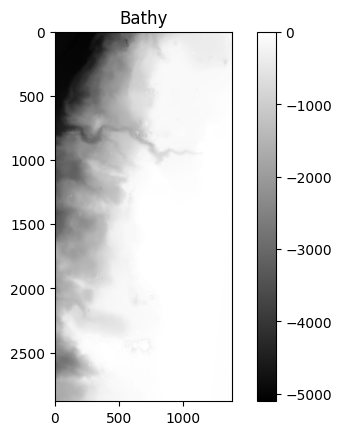

In [60]:
plt.imshow(DEMInt, cmap='gray',)
plt.colorbar()
plt.title('Bathy')
plt.show()

## Lee la grilla de interpolación (DEM)

algo lenta por la busqueda

verifica los limites.

In [61]:
grilla,CRSgrilla,bordes,transform = extrae_Raster(ArchDem)

In [62]:
AA

,N,X,Y,Z,Borde
0,1,-73.103745,-36.616721,0.0,1
1,2,-73.519176,-37.077013,0.0,1
2,3,-73.950619,-38.363430,0.0,1
3,4,-73.071275,-36.647942,0.0,1
4,5,-73.106885,-36.614770,0.0,1
...,...,...,...,...,...
20809,20810,-73.466272,-36.813545,0.0,0
20810,20811,-73.261034,-36.729462,0.0,0
20811,20812,-73.184557,-36.672795,0.0,0
20812,20813,-73.839874,-36.581866,0.0,0


In [63]:
CC = interpolar_valores_desde_raster(ArchDem, AA, crs='EPSG:4326')

In [64]:
CC

,N,X,Y,Z,Borde
0,1,-73.103745,-36.616721,0.000000,1
1,2,-73.519176,-37.077013,-1.435269,1
2,3,-73.950619,-38.363430,0.000000,1
3,4,-73.071275,-36.647942,-2.107021,1
4,5,-73.106885,-36.614770,-0.141440,1
...,...,...,...,...,...
20809,20810,-73.466272,-36.813545,-514.419877,0
20810,20811,-73.261034,-36.729462,-131.998790,0
20811,20812,-73.184557,-36.672795,-84.071818,0
20812,20813,-73.839874,-36.581866,-1800.227307,0


## CONDICION DE BORDE OELAJE (K=2)

Incorpora el valor 2 para los nodos de condición de borde.

In [65]:
Depth_limit = -50.0
CC.loc[(CC['Z'] < Depth_limit) & (CC['Borde'] == 1), 'Borde'] = 2


# Guarda como SWAN TRIANGLE

In [66]:
GenericName = "Malla"
NodeArch = os.path.join(dirOutput,GenericName +".node")
ElemArch = os.path.join(dirOutput,GenericName +".ele")
BotArch = os.path.join(dirOutput,GenericName +".bot")

### Save .nod

In [67]:
# Formato
# First line: <# of nodes> <dimension (must be 2)> <# of attributes> <# of boundary markers (0 or 1)>
# example 
#255521 2 0 1
node_id = AA["N"].to_numpy()
node_id = node_id.astype(np.int32)
TotalNodes = np.shape(node_id)[0]
Dimentions = str(2)
NumAtributes = str(0)
BoundatMarks = str(1)

header = f"{TotalNodes} {Dimentions} {NumAtributes} {BoundatMarks}\n "

x = AA["X"].to_numpy()
y = AA["Y"].to_numpy()
bor = AA["Borde"].to_numpy()

# to create the output file
fout = open(NodeArch,"w")
fout.write(header)
for i in range(0,len(node_id)):
    line = f"{int(node_id[i])} {x[i]:.6f} {y[i]:.6f} {int(bor[i])}\n"
    fout.write(line)
fout.close()

### Save .ele

In [68]:
#Formato
#First line: <# of triangles> <nodes per triangle> <# of attributes>
#Remaining lines: <triangle #> <node> <node> <node> ... [attributes]
Elem_id = B["ID"].to_numpy()
Elem_id = Elem_id.astype(np.int32)
TotalElem = np.shape(Elem_id)[0]
El1 = B["ELEMENT1"].to_numpy()
El2 = B["ELEMENT2"].to_numpy()
El3 = B["ELEMENT3"].to_numpy()
print(TotalElem)
NodesPerTrian = 3

header = f"{TotalElem} {NodesPerTrian} {NumAtributes}\n"
# to create the output file
fout = open(ElemArch,"w")
fout.write(header)
for i in range(0,len(Elem_id)):
    line = f"{Elem_id[i]} {El1[i]} {El3[i]} {El2[i]}\n"  ## counter clock wise (CCW) por eso ele3 es antes.
    fout.write(line)
fout.close()

40764


### Save .bot

In [69]:

z = CC["Z"].to_numpy()

# to create the output file
fout = open(BotArch,"w")
for i in range(0,len(node_id)):
    line = f"{z[i]:.3f} \n"
    fout.write(line)
fout.close()

In [70]:
print(BotArch)

/home/model2/trabajo/sanVicente/output/Malla.bot
